# 📱 Dataset 2: Telco Customer Churn Prediction
## Kỹ thuật: SMOTE + Class Imbalance Handling + Logistic Regression

**Pipeline:** EDA → Phân tích Imbalance → Encoding → SMOTE → Training → Evaluation

---

## 📦 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)
from imblearn.over_sampling import SMOTE
import warnings, os

import random

SEED = 42

os.environ['PYTHONHASHSEED'] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
sns.set_theme(style='whitegrid', palette='husl')

SAVE_DIR = '../results/telco'
os.makedirs(SAVE_DIR, exist_ok=True)
DATA_PATH = '../data/telco_churn/WA_Fn-UseC_-Telco-Customer-Churn.csv'
print('✅ Libraries loaded')

✅ Libraries loaded


## 📂 1. Load Data & Tổng quan

In [2]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
info = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'unique': df.nunique()
})
display(info)
print(f'\nChurn rate: {(df["Churn"]=="Yes").mean()*100:.2f}%')

,dtype,null_count,unique
customerID,object,0,7043
gender,object,0,2
SeniorCitizen,int64,0,2
Partner,object,0,2
Dependents,object,0,2
tenure,int64,0,73
PhoneService,object,0,2
MultipleLines,object,0,3
InternetService,object,0,3
OnlineSecurity,object,0,3



Churn rate: 26.54%


## 📊 2. EDA — Phân tích Churn

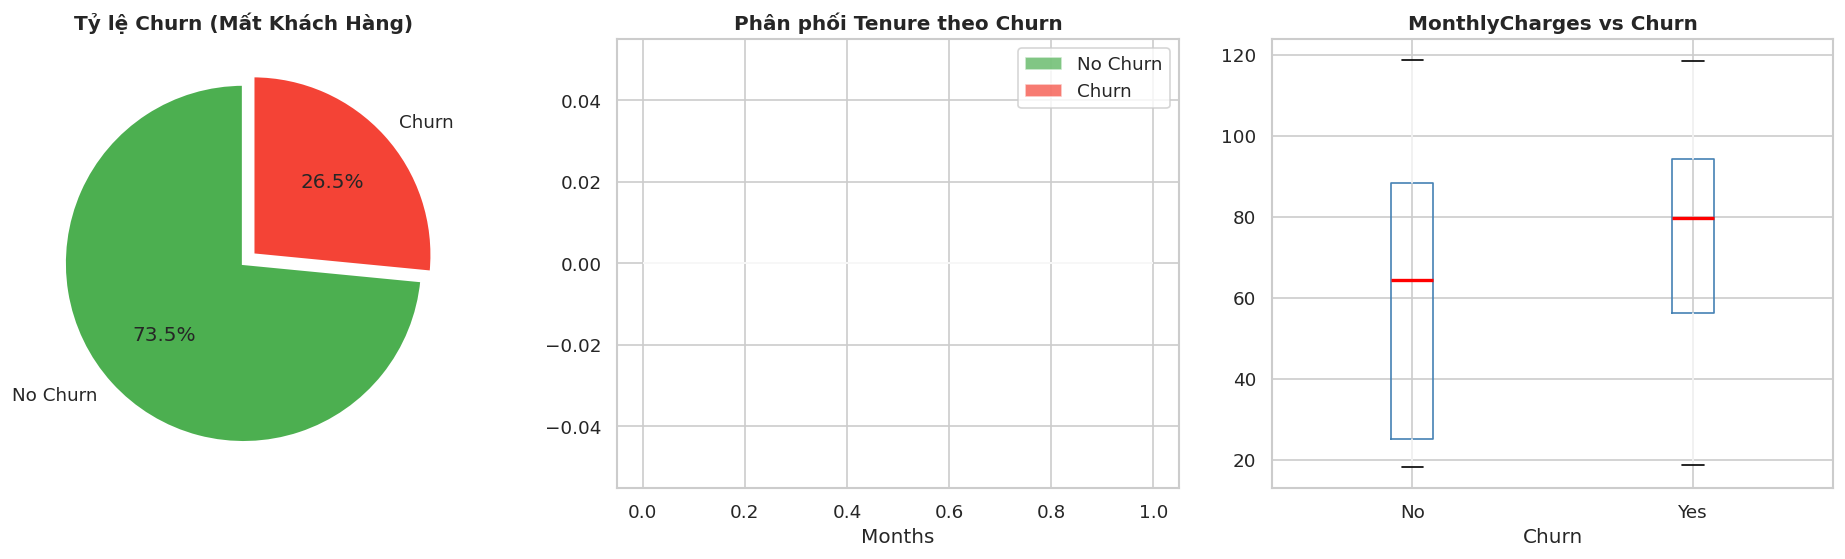

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pie chart churn
churn_counts = df['Churn'].value_counts()

axes[0].pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],
    explode=(0, 0.07),
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

axes[0].set_title('Tỷ lệ Churn (Mất Khách Hàng)')


# Histogram tenure
df[df['Churn'] == 0]['tenure'].hist(
    bins=30,
    ax=axes[1],
    alpha=0.7,
    color='#4CAF50',
    label='No Churn'
)

df[df['Churn'] == 1]['tenure'].hist(
    bins=30,
    ax=axes[1],
    alpha=0.7,
    color='#F44336',
    label='Churn'
)

axes[1].set_title('Phân phối Tenure theo Churn')
axes[1].set_xlabel('Months')
axes[1].legend()


# Boxplot
df.boxplot(
    column='MonthlyCharges',
    by='Churn',
    ax=axes[2],
    boxprops=dict(color='steelblue'),
    medianprops=dict(color='red', linewidth=2)
)

axes[2].set_title('MonthlyCharges vs Churn')
axes[2].set_xlabel('Churn')

plt.suptitle('')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_churn_eda.png', bbox_inches='tight')
plt.show()

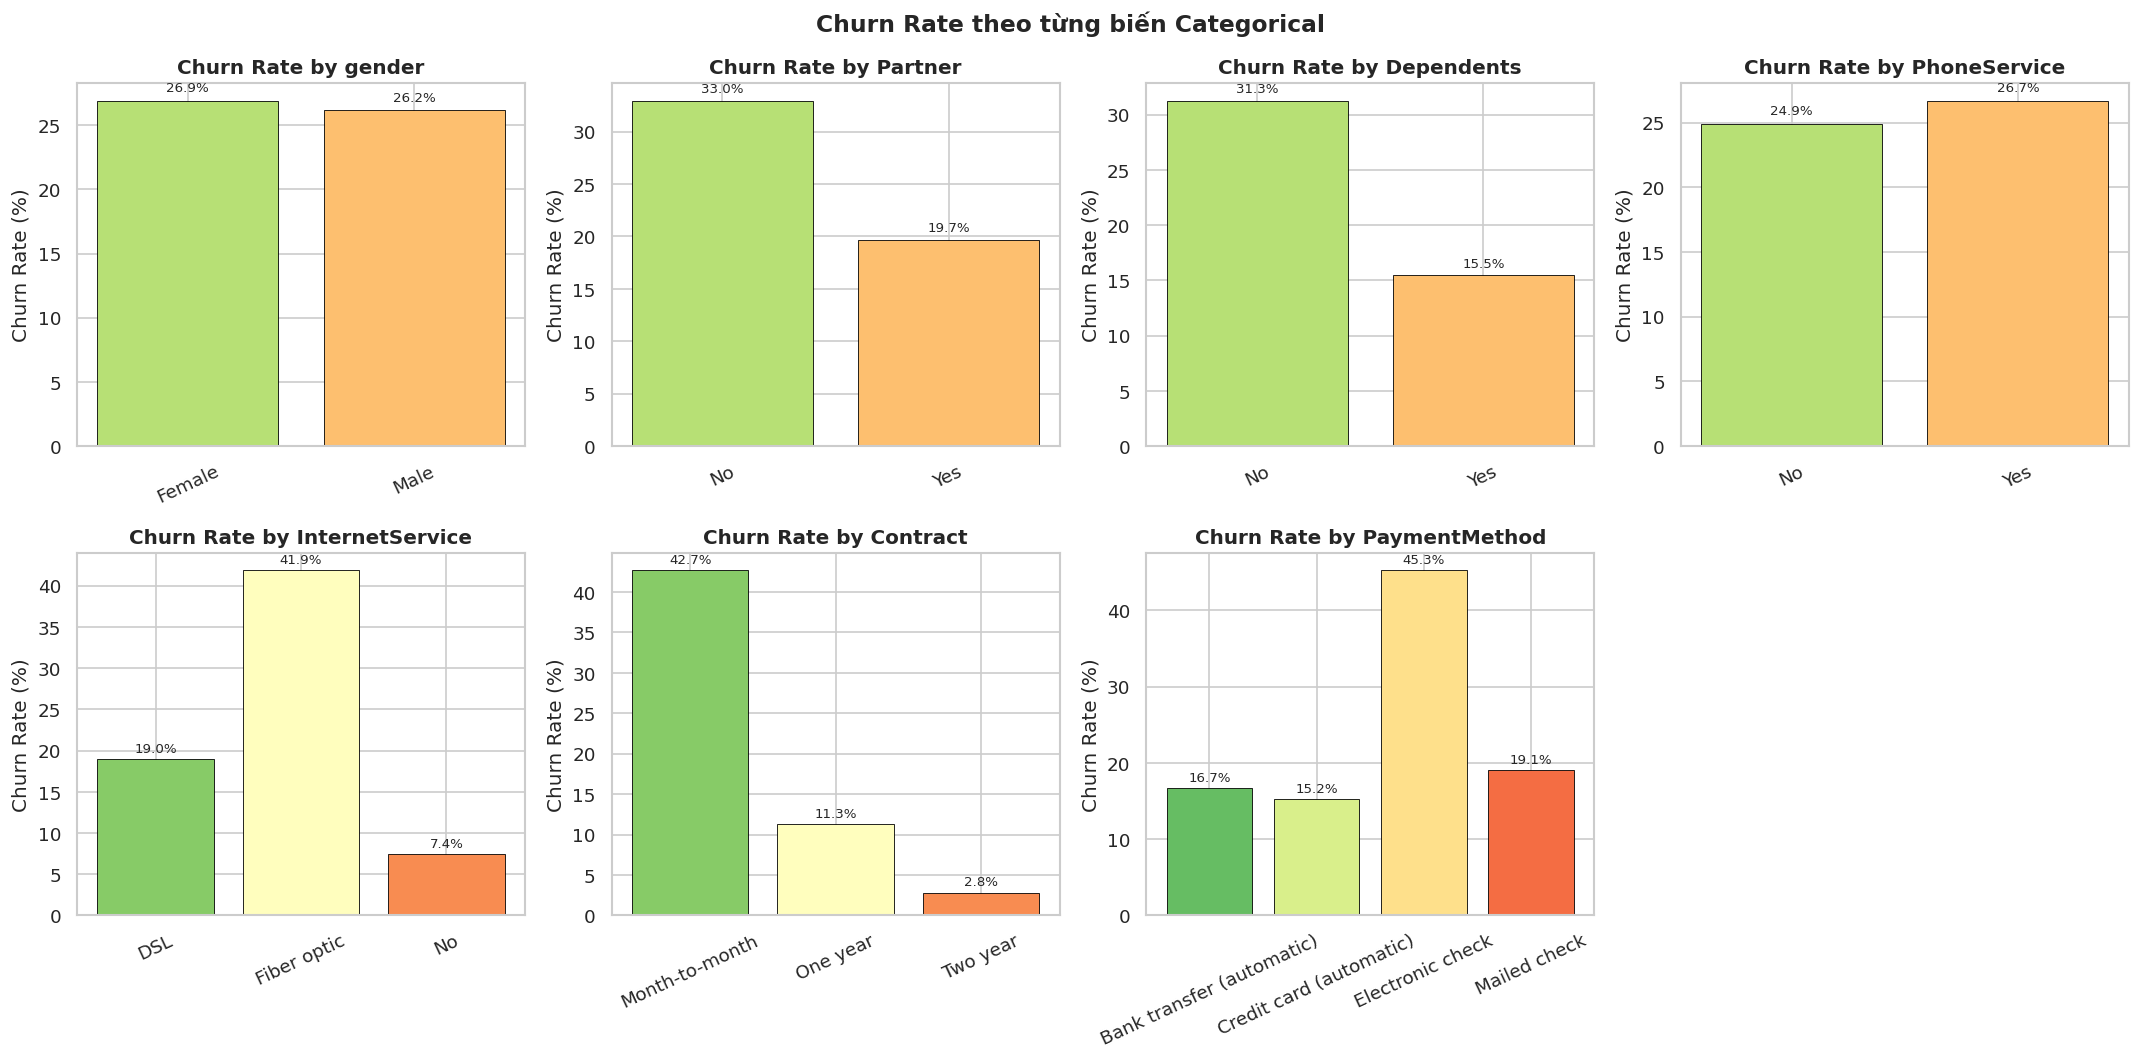

In [5]:
# Categorical features vs Churn rate
cat_features = ['gender', 'Partner', 'Dependents', 'PhoneService',
                'InternetService', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x=='Yes').mean() * 100)
    bars = axes[i].bar(churn_rate.index, churn_rate.values,
                       color=sns.color_palette('RdYlGn_r', len(churn_rate)),
                       edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Churn Rate by {col}')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Churn Rate theo từng biến Categorical', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_churn_by_category.png', bbox_inches='tight')
plt.show()

## ⚙️ 3. Preprocessing & Encoding

In [6]:
df_proc = df.copy()
df_proc['TotalCharges'] = pd.to_numeric(df_proc['TotalCharges'], errors='coerce')
df_proc['TotalCharges'] = df_proc['TotalCharges'].fillna(df_proc['TotalCharges'].median())
df_proc = df_proc.drop('customerID', axis=1)

# Binary encode
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df_proc[col] = le.fit_transform(df_proc[col])

# One-hot encode
df_proc = pd.get_dummies(df_proc)
print(f'Shape after encoding: {df_proc.shape}')
df_proc.head(3)

Shape after encoding: (7043, 41)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True


## ⚖️ 4. SMOTE — Xử lý Class Imbalance

In [7]:
X = df_proc.drop('Churn', axis=1)
y = df_proc['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f'Before SMOTE — Train: {X_train.shape}, Churn rate: {y_train.mean():.3f}')

smote = SMOTE(random_state=SEED)
X_res, y_res = smote.fit_resample(X_train, y_train)

print(f'After  SMOTE — Train: {X_res.shape}, Churn rate: {y_res.mean():.3f}')

Before SMOTE — Train: (5634, 40), Churn rate: 0.265
After  SMOTE — Train: (8278, 40), Churn rate: 0.500


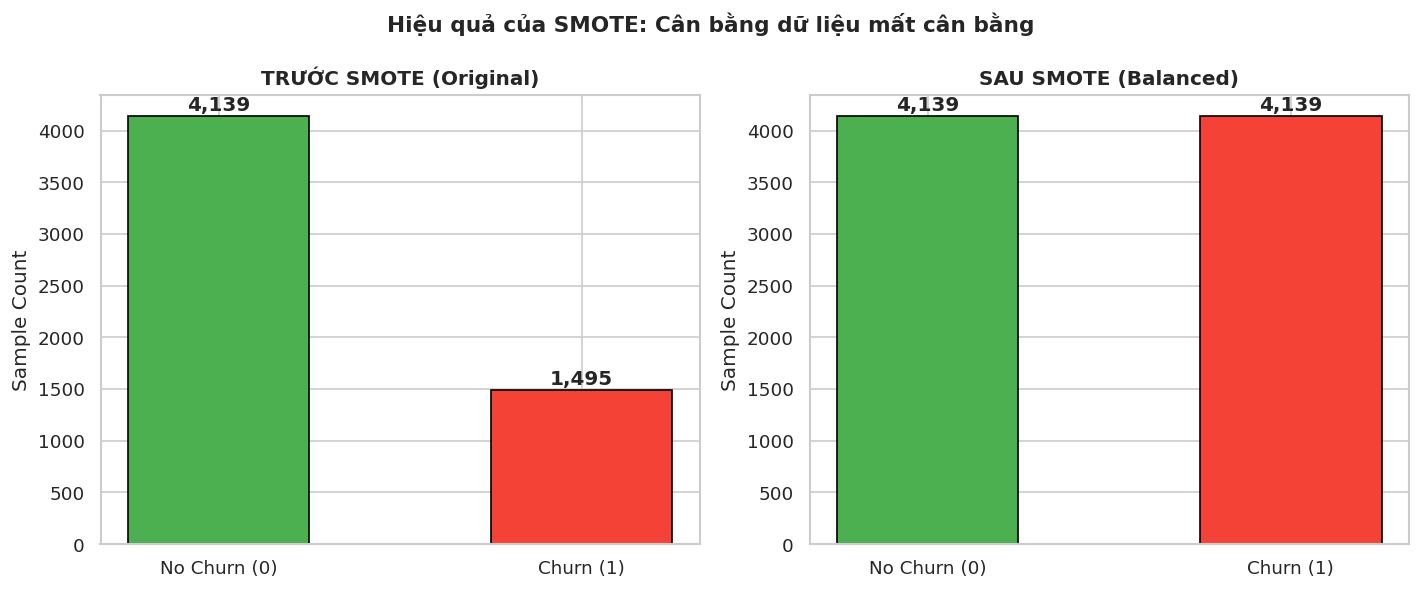

In [8]:
# Visualize SMOTE effect
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (data, title) in zip(axes, [
    (y_train, 'TRƯỚC SMOTE (Original)'),
    (y_res,   'SAU SMOTE (Balanced)')
]):
    counts = pd.Series(data).value_counts()
    bars = ax.bar(['No Churn (0)', 'Churn (1)'],
                  [counts.get(0,0), counts.get(1,0)],
                  color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)
    ax.set_title(title)
    ax.set_ylabel('Sample Count')
    for bar, val in zip(bars, [counts.get(0,0), counts.get(1,0)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{val:,}', ha='center', fontweight='bold')

plt.suptitle('Hiệu quả của SMOTE: Cân bằng dữ liệu mất cân bằng', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_smote_comparison.png', bbox_inches='tight')
plt.show()

## 🤖 5. Training & Evaluation

In [9]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_res)
X_test_s  = scaler.transform(X_test)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
}

results = {}
for name, mdl in models.items():
    mdl.fit(X_train_s, y_res)
    preds = mdl.predict(X_test_s)
    proba = mdl.predict_proba(X_test_s)[:, 1]
    acc   = accuracy_score(y_test, preds)
    auc   = roc_auc_score(y_test, proba)
    results[name] = {'model': mdl, 'preds': preds, 'proba': proba, 'Accuracy': acc, 'AUC': auc}
    print(f'{name:25s} | Accuracy={acc:.4f} | ROC-AUC={auc:.4f}')

Logistic Regression       | Accuracy=0.7949 | ROC-AUC=0.8407
Random Forest             | Accuracy=0.7786 | ROC-AUC=0.8197


Best model: Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.86      0.86      0.86      1035
       Churn       0.61      0.61      0.61       374

    accuracy                           0.79      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.79      0.79      0.79      1409



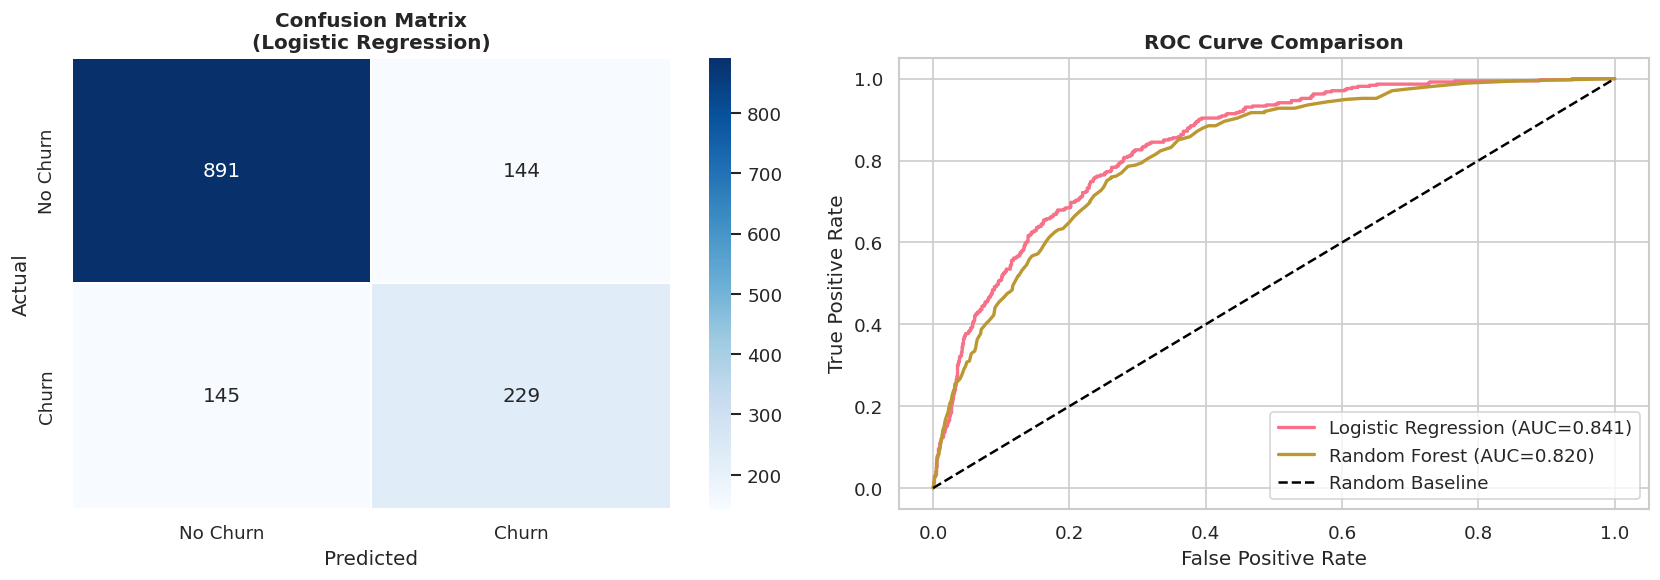

In [10]:
# Confusion Matrix + ROC Curve for best model
best_name = max(results, key=lambda m: results[m]['AUC'])
best = results[best_name]
print(f'Best model: {best_name}')
print(classification_report(y_test, best['preds'], target_names=['No Churn', 'Churn']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, best['preds'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            linewidths=1, linecolor='white')
axes[0].set_title(f'Confusion Matrix\n({best_name})')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curves
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[1].plot(fpr, tpr, lw=2, label=f'{name} (AUC={res["AUC"]:.3f})')

axes[1].plot([0,1], [0,1], 'k--', lw=1.5, label='Random Baseline')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_roc.png', bbox_inches='tight')
plt.show()

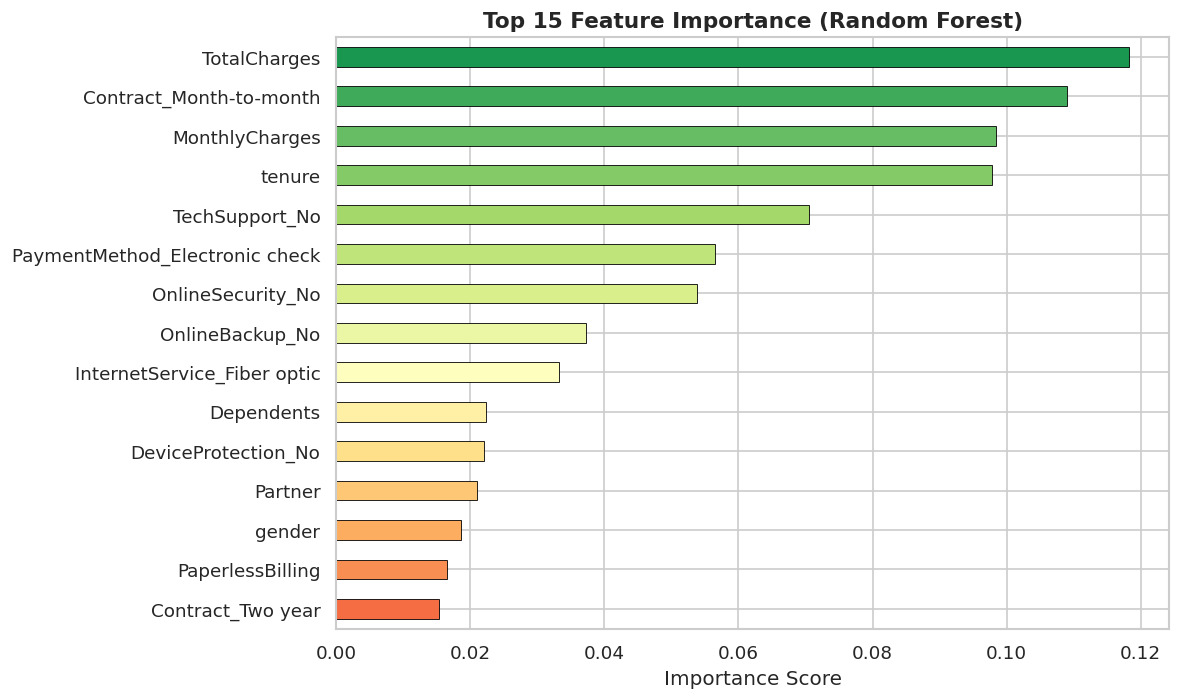

In [11]:
# Feature importance (top 15)
rf = results['Random Forest']['model']
fi = pd.Series(rf.feature_importances_, index=X.columns)
fi_top = fi.nlargest(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(fi_top)))
fi_top.plot(kind='barh', ax=ax, color=colors_fi, edgecolor='black', linewidth=0.5)
ax.set_title('Top 15 Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/05_feature_importance.png', bbox_inches='tight')
plt.show()

In [12]:
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Telco Churn Classification Report (with SMOTE)\n')
    f.write('='*50 + '\n')
    for name, res in results.items():
        f.write(f'\n[{name}]\n')
        f.write(f'  Accuracy : {res["Accuracy"]:.4f}\n')
        f.write(f'  ROC-AUC  : {res["AUC"]:.4f}\n')
        f.write(classification_report(y_test, res['preds'], target_names=['No Churn','Churn']))

print('✅ Telco Churn Experiment Completed! Results saved to', SAVE_DIR)

✅ Telco Churn Experiment Completed! Results saved to ../results/telco
